In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving Engg_College_Data.csv to Engg_College_Data.csv


In [ ]:
df = pd.read_csv('Engg_College_Data.csv')  # Replace with the correct filename
print(df.head())  # Show the first 5 rows

   SR_NO Engg_College  Teaching  Fees  Placements  Internship  Infrastructure
0      1            A         5     2           5           5               3
1      2            B         4     2           5           5               3
2      3            C         4     5           5           4               5
3      4            D         5     4           5           4               4
4      5            E         2     5           2           2               5


In [ ]:
df.head()


,SR_NO,Engg_College,Teaching,Fees,Placements,Internship,Infrastructure
0,1,A,5,2,5,5,3
1,2,B,4,2,5,5,3
2,3,C,4,5,5,4,5
3,4,D,5,4,5,4,4
4,5,E,2,5,2,2,5


In [ ]:
df.shape


(26, 7)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   SR_NO           26 non-null     int64 
 1   Engg_College    26 non-null     object
 2   Teaching        26 non-null     int64 
 3   Fees            26 non-null     int64 
 4   Placements      26 non-null     int64 
 5   Internship      26 non-null     int64 
 6   Infrastructure  26 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 1.6+ KB


In [ ]:
# Get the count of unique values
unique_count = df['Engg_College'].nunique()
print("Number of unique engineering colleges:", unique_count)


Number of unique engineering colleges: 26


In [ ]:
# Get the list of unique values
unique_values = df['Engg_College'].unique()
print("Unique engineering colleges:", unique_values)


Unique engineering colleges: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [ ]:
# Checking the Summary Statistic
df.describe()


,SR_NO,Teaching,Fees,Placements,Internship,Infrastructure
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,13.500000,2.807692,3.576923,2.884615,2.769231,3.384615
std,7.648529,1.132051,1.331858,1.531716,1.242826,1.298520
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,7.250000,2.000000,2.250000,1.250000,2.000000,3.000000
50%,13.500000,3.000000,4.000000,3.000000,2.000000,3.000000
75%,19.750000,3.000000,5.000000,4.000000,4.000000,4.750000
max,26.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:
## Removing the SR_NO column and storing the result in new object enggdata
enggdata = df.drop(columns=['SR_NO'])


In [ ]:
enggdata.head()


,Engg_College,Teaching,Fees,Placements,Internship,Infrastructure
0,A,5,2,5,5,3
1,B,4,2,5,5,3
2,C,4,5,5,4,5
3,D,5,4,5,4,4
4,E,2,5,2,2,5


In [ ]:
#Creating the Dendrogram
#Imported dendrogram and linkage module
#Choosing average linkage method

In [ ]:
link_method = linkage(enggdata.iloc[:,1:6], method = 'average')


In [ ]:
labelList = np.array(enggdata.Engg_College)
labelList

array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
       'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'],
      dtype=object)

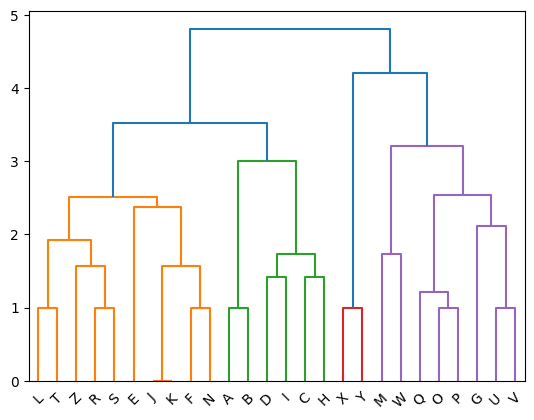

In [ ]:
dend = dendrogram(link_method,labels = labelList)

In [ ]:
#Cutting the Dendrogram with suitable clusters

In [ ]:
#Importing fcluster module to create clusters
from scipy.cluster.hierarchy import fcluster


In [ ]:
# Appending clusters to original dataset
clusters = fcluster(link_method, t=3, criterion='maxclust')
df['clusters'] = clusters

In [ ]:
df.head(26)

,SR_NO,Engg_College,Teaching,Fees,Placements,Internship,Infrastructure,clusters
0,1,A,5,2,5,5,3,1
1,2,B,4,2,5,5,3,1
2,3,C,4,5,5,4,5,1
3,4,D,5,4,5,4,4,1
4,5,E,2,5,2,2,5,1
5,6,F,3,4,3,3,4,1
6,7,G,1,3,1,1,2,3
7,8,H,4,4,5,5,5,1
8,9,I,4,4,4,4,4,1
9,10,J,3,4,3,4,5,1


In [ ]:
# Cluster Frequency (counted how many colleges are in each cluster)
df.clusters.value_counts().sort_index()

,count
clusters,
1,16
2,2
3,8


In [ ]:
## Cluster Profiles (summarizing the average values of features (Teaching, Fees, Placements, Internship, Infrastructure) for each cluster, and adding cluster frequency.)
# Drop non-numeric columns before grouping to avoid errors
numeric_cols = ['Teaching', 'Fees', 'Placements', 'Internship', 'Infrastructure']

# Group by clusters and calculate mean of numeric features
cluster_profiles = df.groupby('clusters')[numeric_cols].mean()

# Add frequency (number of colleges in each cluster)
cluster_profiles['Freq'] = df['clusters'].value_counts().sort_index()

# Display the cluster profiles
print(cluster_profiles)




          Teaching   Fees  Placements  Internship  Infrastructure  Freq
clusters                                                               
1            3.375  4.125       3.875      3.4375           3.875    16
2            1.000  1.000       1.000      1.5000           5.000     2
3            2.125  3.125       1.375      1.7500           2.000     8


In [ ]:
tier_labels = {
    1: 'Tier 1 colleges (Top Colleges)',
    2: 'Tier 3 colleges (Poor performing/new college)',
    3: 'Tier 2 colleges (Medium performing)'
}

cluster_profiles['Tier'] = cluster_profiles.index.map(tier_labels)

print(cluster_profiles)


          Teaching   Fees  Placements  Internship  Infrastructure  Freq  \
clusters                                                                  
1            3.375  4.125       3.875      3.4375           3.875    16   
2            1.000  1.000       1.000      1.5000           5.000     2   
3            2.125  3.125       1.375      1.7500           2.000     8   

                                                   Tier  
clusters                                                 
1                        Tier 1 colleges (Top Colleges)  
2         Tier 3 colleges (Poor performing/new college)  
3                   Tier 2 colleges (Medium performing)  


In [ ]:
# Step 1: Map cluster numbers to tier labels
tier_labels = {
    1: 'Tier 1 colleges (Top Colleges)',
    2: 'Tier 3 colleges (Poor performing/new college)',
    3: 'Tier 2 colleges (Medium performing)'
}

# Step 2: Add 'Tier' column to cluster_profiles based on cluster index
cluster_profiles['Tier'] = cluster_profiles.index.map(tier_labels)

# ✅ Step 3: Merge the 'Tier' info into your main DataFrame 'df'
df = pd.merge(df, cluster_profiles[['Tier']], left_on='clusters', right_index=True)

# ✅ Step 4: Display the merged result with selected columns
print(df[['Engg_College', 'clusters', 'Tier']])



   Engg_College  clusters                                           Tier
0             A         1                 Tier 1 colleges (Top Colleges)
1             B         1                 Tier 1 colleges (Top Colleges)
2             C         1                 Tier 1 colleges (Top Colleges)
3             D         1                 Tier 1 colleges (Top Colleges)
4             E         1                 Tier 1 colleges (Top Colleges)
5             F         1                 Tier 1 colleges (Top Colleges)
6             G         3            Tier 2 colleges (Medium performing)
7             H         1                 Tier 1 colleges (Top Colleges)
8             I         1                 Tier 1 colleges (Top Colleges)
9             J         1                 Tier 1 colleges (Top Colleges)
10            K         1                 Tier 1 colleges (Top Colleges)
11            L         1                 Tier 1 colleges (Top Colleges)
12            M         3            Tier 2 college

In [ ]:
# Tier 1 colleges
print("Tier 1 Colleges:")
print(df[df['Tier'] == 'Tier 1 colleges (Top Colleges)'][['Engg_College', 'clusters']])

# Tier 2 colleges
print("\nTier 2 Colleges:")
print(df[df['Tier'] == 'Tier 2 colleges (Medium performing)'][['Engg_College', 'clusters']])

# Tier 3 colleges
print("\nTier 3 Colleges:")
print(df[df['Tier'] == 'Tier 3 colleges (Poor performing/new college)'][['Engg_College', 'clusters']])


Tier 1 Colleges:
   Engg_College  clusters
0             A         1
1             B         1
2             C         1
3             D         1
4             E         1
5             F         1
7             H         1
8             I         1
9             J         1
10            K         1
11            L         1
13            N         1
17            R         1
18            S         1
19            T         1
25            Z         1

Tier 2 Colleges:
   Engg_College  clusters
6             G         3
12            M         3
14            O         3
15            P         3
16            Q         3
20            U         3
21            V         3
22            W         3

Tier 3 Colleges:
   Engg_College  clusters
23            X         2
24            Y         2


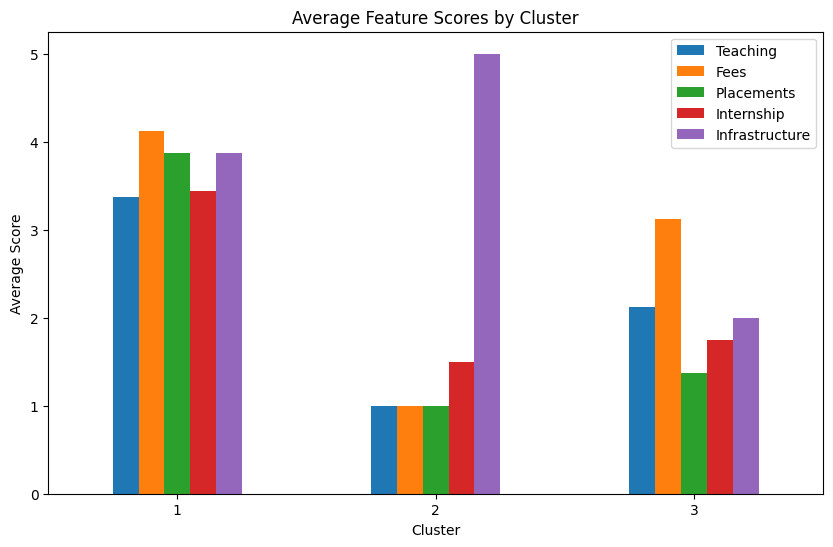

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have cluster_profiles from before
cluster_profiles.drop(columns=['Freq', 'Tier'], errors='ignore').plot(kind='bar', figsize=(10,6))
plt.title('Average Feature Scores by Cluster')
plt.ylabel('Average Score')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.legend(loc='best')
plt.show()


In [ ]:
from sklearn.cluster import AgglomerativeClustering


In [ ]:
# Set n_clusters=3,affinity='euclidean', linkage='average' and store the result in another object 'Cluster_agglo'

cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='average')
Cluster_agglo=cluster.fit_predict(enggdata.iloc[:,1:6])
print(Cluster_agglo)

[0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 1 1 1 2 2 0]


In [ ]:
df["Agglo_CLusters"]=Cluster_agglo


In [ ]:
df.Agglo_CLusters.value_counts().sort_index()


,count
Agglo_CLusters,
0,16
1,8
2,2


In [ ]:
# Select only the numeric columns for calculating the mean
numeric_cols = ['Teaching', 'Fees', 'Placements', 'Internship', 'Infrastructure']

# Group by Agglo_CLusters and calculate the mean of the numeric columns
agglo_data = df.groupby('Agglo_CLusters')[numeric_cols].mean()

# Add the frequency (number of colleges in each cluster)
agglo_data['Freq'] = df['Agglo_CLusters'].value_counts().sort_index()

# Display the aggregated data
display(agglo_data)

,Teaching,Fees,Placements,Internship,Infrastructure,Freq
Agglo_CLusters,,,,,,
0,3.375,4.125,3.875,3.4375,3.875,16
1,2.125,3.125,1.375,1.7500,2.000,8
2,1.000,1.000,1.000,1.5000,5.000,2
